In [2]:
from matplotlib import pyplot as plt
import numpy as np

In [3]:
x = np.linspace(-1.6, 1.6, 17)
y = np.cos(x)

x, y

(array([-1.6, -1.4, -1.2, -1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,
         0.6,  0.8,  1. ,  1.2,  1.4,  1.6]),
 array([-0.02919952,  0.16996714,  0.36235775,  0.54030231,  0.69670671,
         0.82533561,  0.92106099,  0.98006658,  1.        ,  0.98006658,
         0.92106099,  0.82533561,  0.69670671,  0.54030231,  0.36235775,
         0.16996714, -0.02919952]))

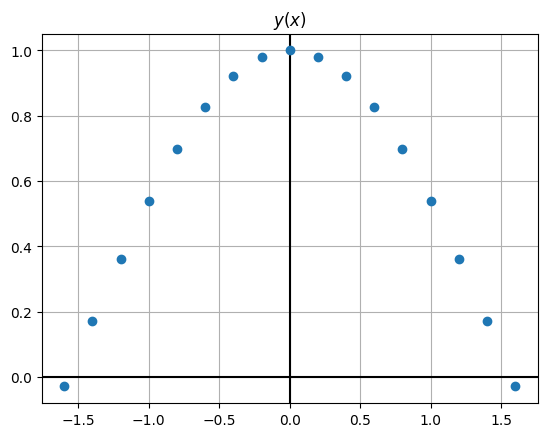

In [4]:
plt.grid(True); plt.axhline(0.0, c='k'); plt.axvline(0.0, c='k')
plt.plot(x, y, 'o')
plt.title('$y(x)$')
plt.show()

In [6]:
X = np.array([x**2, x, np.ones_like(x)]).T
X

array([[ 2.56, -1.6 ,  1.  ],
       [ 1.96, -1.4 ,  1.  ],
       [ 1.44, -1.2 ,  1.  ],
       [ 1.  , -1.  ,  1.  ],
       [ 0.64, -0.8 ,  1.  ],
       [ 0.36, -0.6 ,  1.  ],
       [ 0.16, -0.4 ,  1.  ],
       [ 0.04, -0.2 ,  1.  ],
       [ 0.  ,  0.  ,  1.  ],
       [ 0.04,  0.2 ,  1.  ],
       [ 0.16,  0.4 ,  1.  ],
       [ 0.36,  0.6 ,  1.  ],
       [ 0.64,  0.8 ,  1.  ],
       [ 1.  ,  1.  ,  1.  ],
       [ 1.44,  1.2 ,  1.  ],
       [ 1.96,  1.4 ,  1.  ],
       [ 2.56,  1.6 ,  1.  ]])

This code calculates 𝜃, which represents the optimal coefficients (weights) for linear regression that minimize the mean squared error (MSE) between the predicted values and actual values. Using this closed-form solution, we can directly find the best-fit line for the data without needing iterative methods like gradient descent.

In [ ]:
theta = np.linalg.inv(X.T @ X) @ (X.T @ y)
theta = np.linalg.solve((X.T @ X) , (X.T @ y))

array([-4.06002619e-01, -5.68245467e-17,  9.74068111e-01])

uses the least squares method to solve for the optimal parameters (coefficients) θ in a linear regression setting
This code finds the best-fit coefficients for a linear model using the least-squares approach. This method is useful for linear regression because it minimizes the sum of squared errors between the predictions and the actual target values 𝑦.
 np.linalg.lstsq is more numerically stable and can handle cases where 𝑋 is not invertible or has linearly dependent columns.

Using theta, *_ = unpacks only the first value returned by np.linalg.lstsq, which is the solution θ, and ignores the other outputs (residuals, rank, and singular values).


In [17]:
theta, *_ = np.linalg.lstsq(X, y, rcond=None)
y_hat= X @ theta

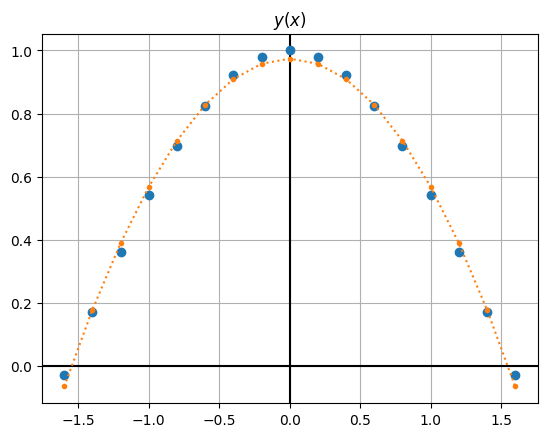

In [18]:
plt.grid(True); plt.axhline(0.0, c='k'); plt.axvline(0.0, c='k')
plt.plot(x, y, 'o')
plt.plot(x, y_hat, ':.')
plt.title('$y(x)$')
plt.show()

In [19]:
error = y_hat - y
error

cost = 0.5 * np.mean(error**2)
cost

0.0002448967193254196

Gradient descent


In [36]:
alpha = 0.5
costs = []
theta = np.zeros(X.shape[1])

for _ in range(50):
    y_hat = X @ theta
    error = y_hat - y
    theta -= (alpha / y.size) * (X.T @ error)
    cost = 1/2 * np.mean(error**2)
    costs.append(cost)
theta

array([-4.05877872e-01, -2.25769158e-17,  9.73894075e-01])

In [37]:
y_hat = X @ theta

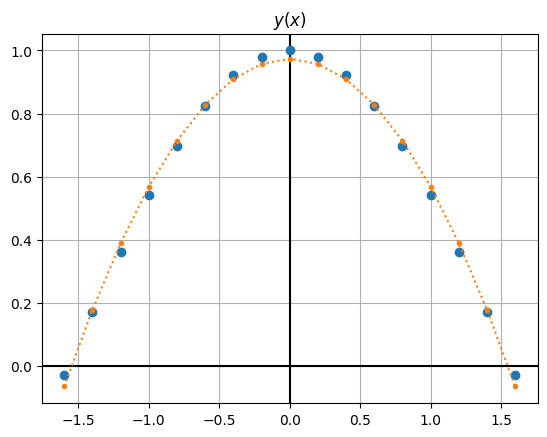

In [38]:
plt.grid(True); plt.axhline(0.0, c='k'); plt.axvline(0.0, c='k')
plt.plot(x, y, 'o')
plt.plot(x, y_hat, ':.')
plt.title('$y(x)$')
plt.show()


In [40]:
error = y_hat - y
cost = 0.5 * np.mean(error ** 2)

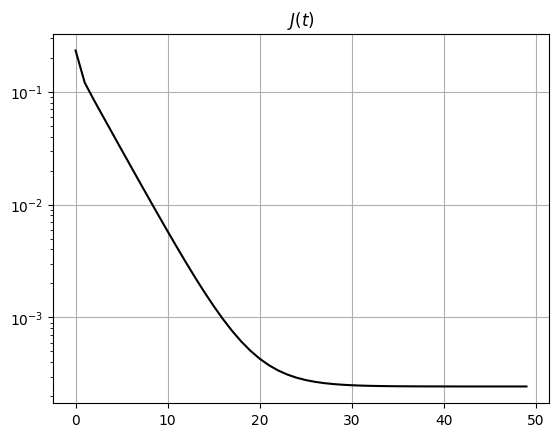

In [41]:
plt.grid(True)
plt.plot(costs, '-k')
plt.title("$J(t)$")
plt.yscale("log")
plt.show()

### Scikit-learn
The demo introduces feature scaling by modifying the 𝑥**2 term to be scaled by a factor of 10, which significantly changes the magnitude of the features.
This section demonstrates how large feature values can lead to instability in gradient descent, as shown by the initial failure to converge. It shows how reducing the learning rate (𝛼) allows gradient descent to stabilize, emphasizing the importance of feature scaling and learning rate selection.